<a href="https://www.kaggle.com/code/janmartins/dv-volcanic-eruptions?scriptVersionId=224990823" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Importando as bibliotecas que vamos usar nessa análise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/volcanic-eruptions/database.csv


In [2]:
# Carregar o dataset

df = pd.read_csv(r'/kaggle/input/volcanic-eruptions/database.csv')

In [3]:
# Mostra a quantidade de linhas e colunas

df.shape

(1508, 12)

In [4]:
# Vamos olhar as primeiras linhas do dataset, como não especificamos um valor vai retornas as 5 primeiras por padrão

df.head()

,Number,Name,Country,Region,Type,Activity Evidence,Last Known Eruption,Latitude,Longitude,Elevation (Meters),Dominant Rock Type,Tectonic Setting
0,210010,West Eifel Volcanic Field,Germany,Mediterranean and Western Asia,Maar(s),Eruption Dated,8300 BCE,50.170,6.85,600,Foidite,Rift Zone / Continental Crust (>25 km)
1,210020,Chaine des Puys,France,Mediterranean and Western Asia,Lava dome(s),Eruption Dated,4040 BCE,45.775,2.97,1464,Basalt / Picro-Basalt,Rift Zone / Continental Crust (>25 km)
2,210030,Olot Volcanic Field,Spain,Mediterranean and Western Asia,Pyroclastic cone(s),Evidence Credible,Unknown,42.170,2.53,893,Trachybasalt / Tephrite Basanite,Intraplate / Continental Crust (>25 km)
3,210040,Calatrava Volcanic Field,Spain,Mediterranean and Western Asia,Pyroclastic cone(s),Eruption Dated,3600 BCE,38.870,-4.02,1117,Basalt / Picro-Basalt,Intraplate / Continental Crust (>25 km)
4,211001,Larderello,Italy,Mediterranean and Western Asia,Explosion crater(s),Eruption Observed,1282 CE,43.250,10.87,500,No Data,Subduction Zone / Continental Crust (>25 km)


In [5]:
# Vamos receber informações sobre o dataset, quantidade de linhas, quais colunas e seus tipos de dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1508 entries, 0 to 1507
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Number               1508 non-null   int64  
 1   Name                 1508 non-null   object 
 2   Country              1508 non-null   object 
 3   Region               1508 non-null   object 
 4   Type                 1508 non-null   object 
 5   Activity Evidence    1507 non-null   object 
 6   Last Known Eruption  1508 non-null   object 
 7   Latitude             1508 non-null   float64
 8   Longitude            1508 non-null   float64
 9   Elevation (Meters)   1508 non-null   int64  
 10  Dominant Rock Type   1455 non-null   object 
 11  Tectonic Setting     1501 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 141.5+ KB


In [6]:
# Vai retornar a soma dos valores nulos por coluna

df.isnull().sum()

Number                  0
Name                    0
Country                 0
Region                  0
Type                    0
Activity Evidence       1
Last Known Eruption     0
Latitude                0
Longitude               0
Elevation (Meters)      0
Dominant Rock Type     53
Tectonic Setting        7
dtype: int64

In [7]:
# A coluna Number é um identificador númerico, vamos nos livrar dela

df.drop('Number', axis=1, inplace=True)

In [8]:
# Preenchemos os valores ausentes da coluna por desconhecido
df['Dominant Rock Type']=df['Dominant Rock Type'].fillna('Desconhecido')
df['Tectonic Setting']=df['Tectonic Setting'].fillna('Desconhecido')
df['Activity Evidence']=df['Activity Evidence'].fillna('Desconhecido')

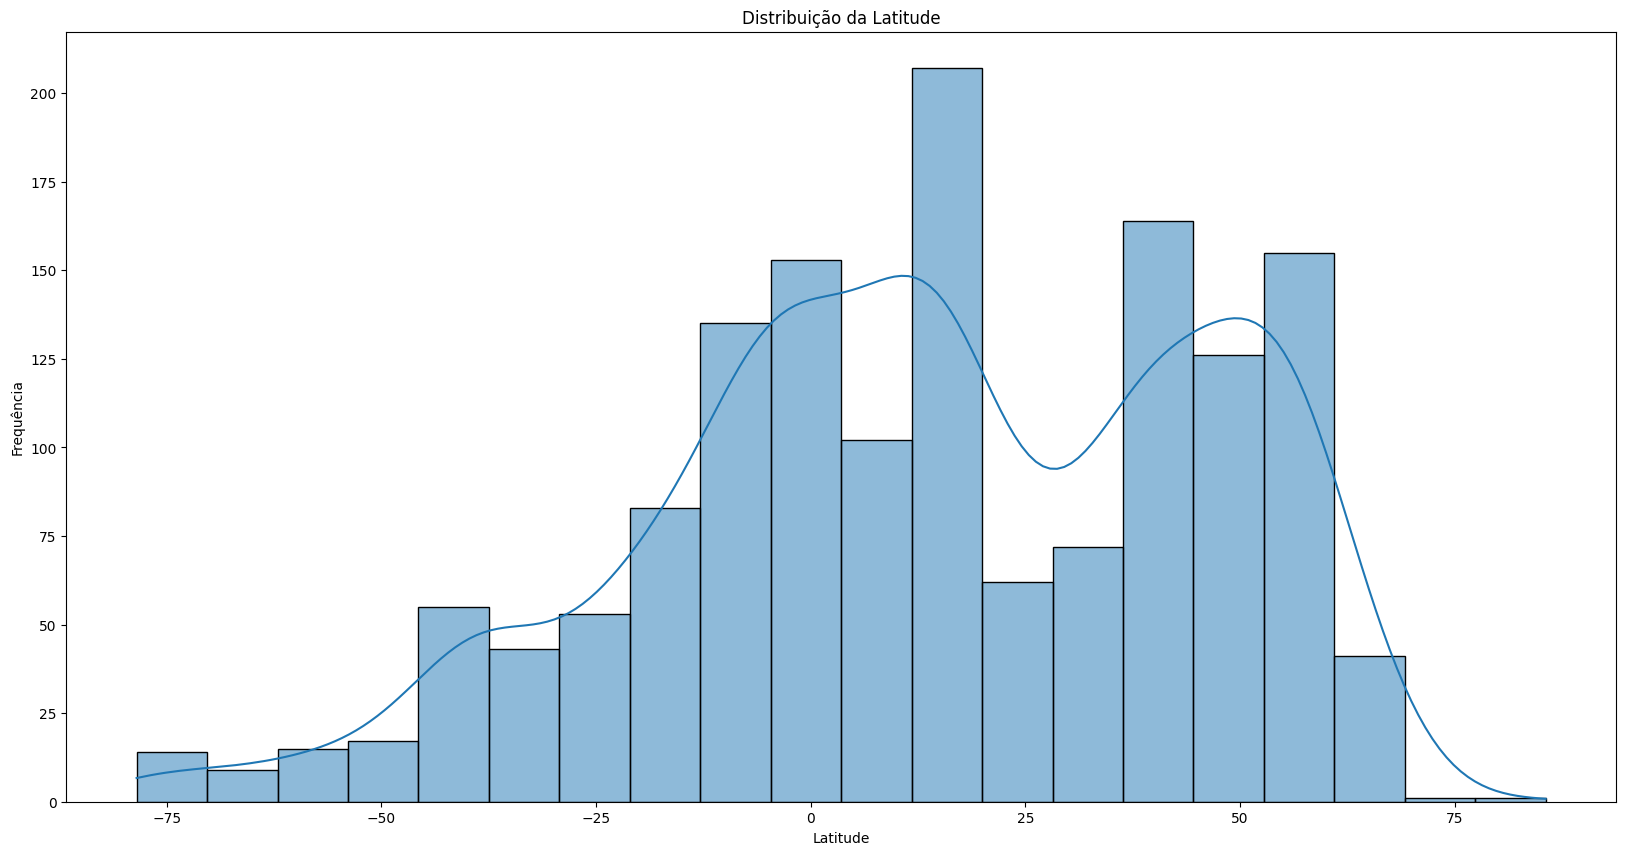

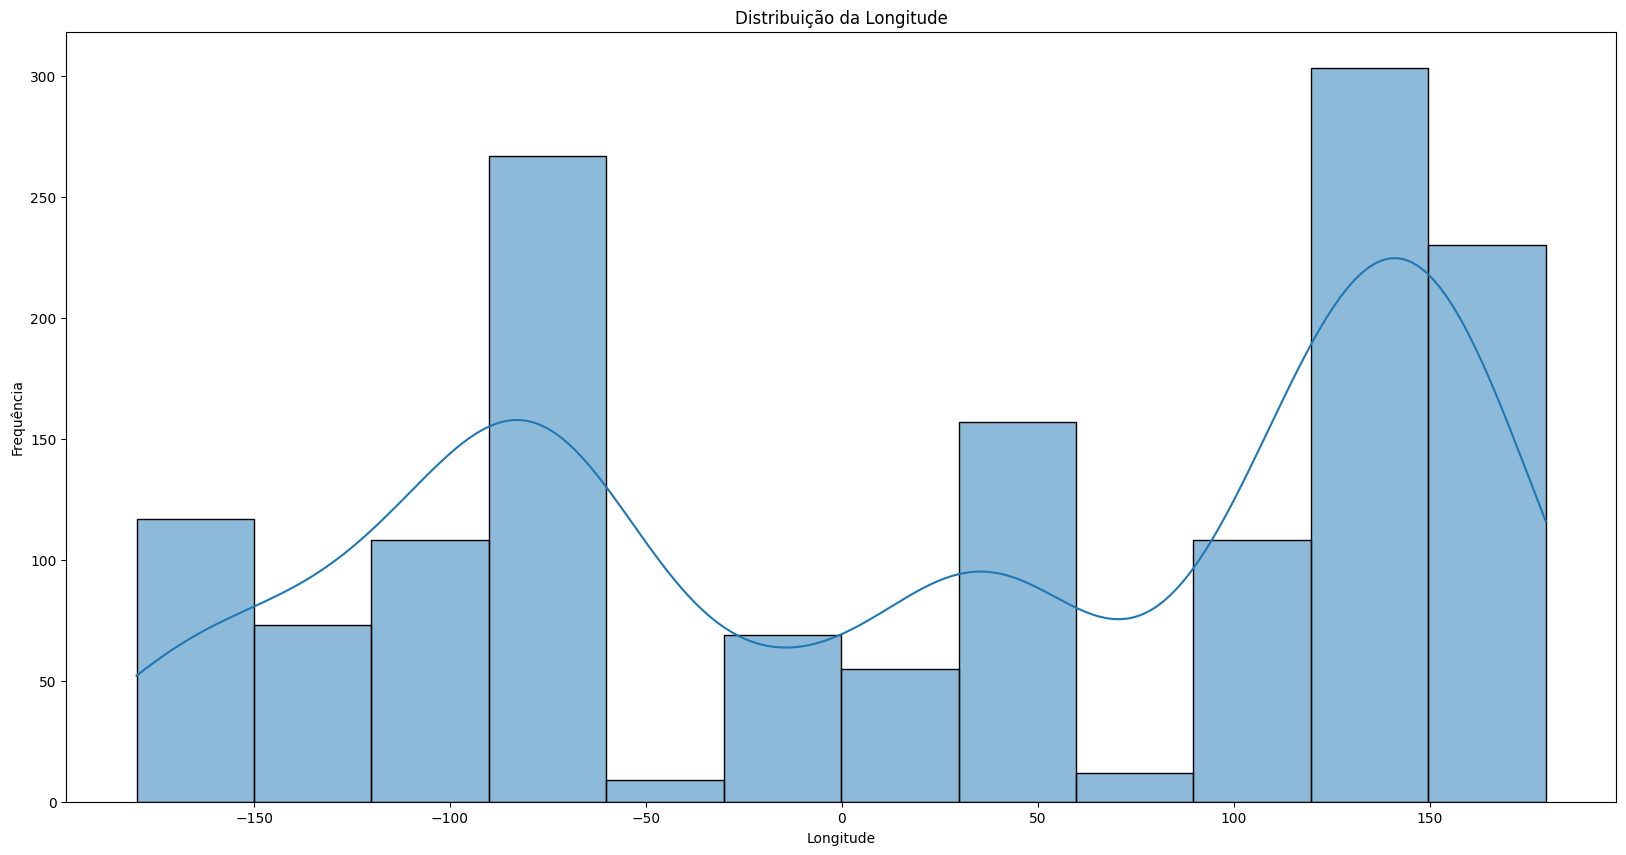

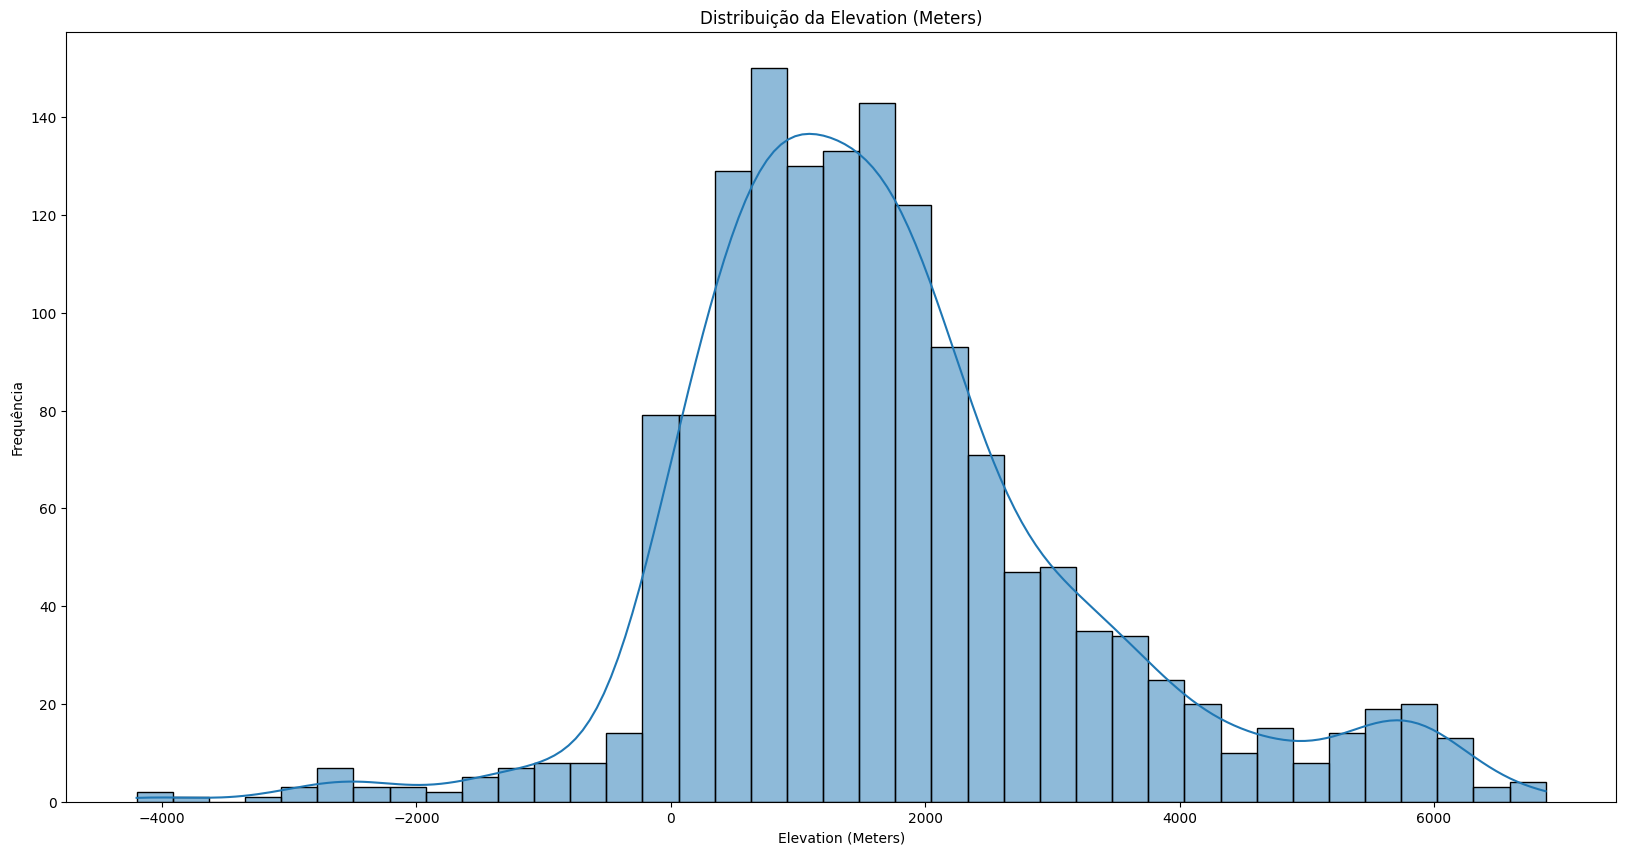

In [9]:
for col in df.columns:
    if df[col].dtype == 'object':
        continue
    plt.figure(figsize=(20,10))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição da {col}')
    plt.xlabel(f'{col}')
    plt.ylabel('Frequência')
    plt.show()

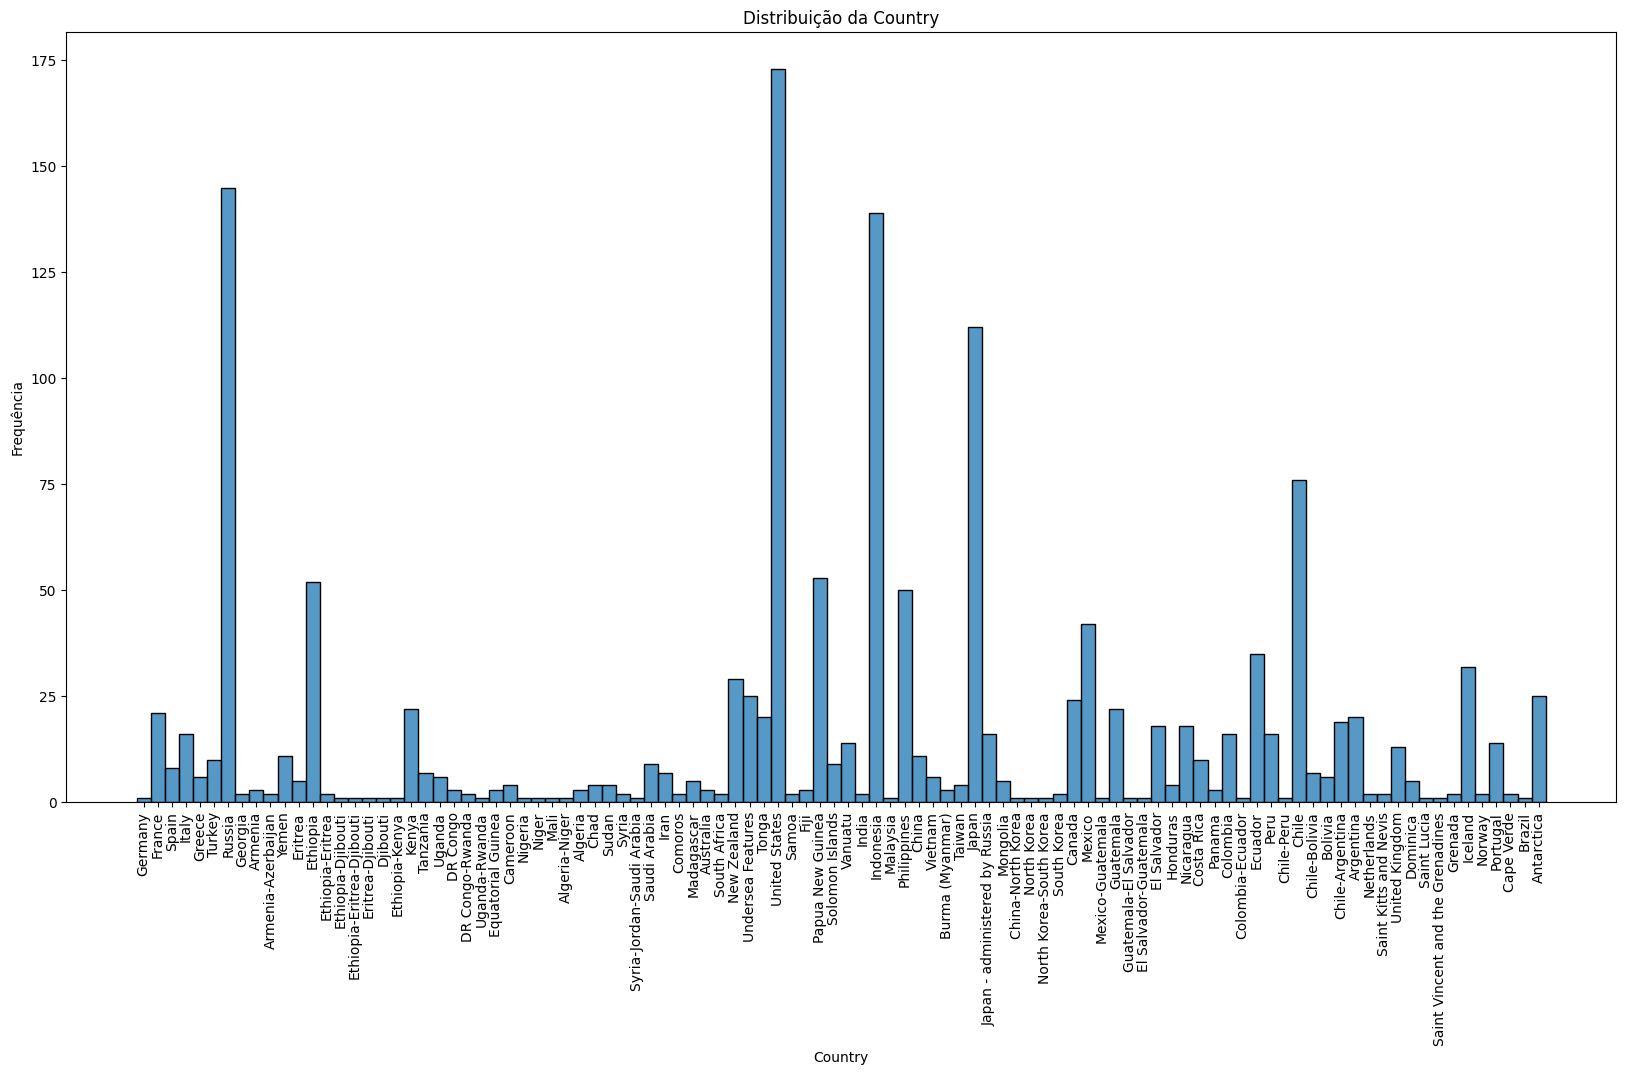

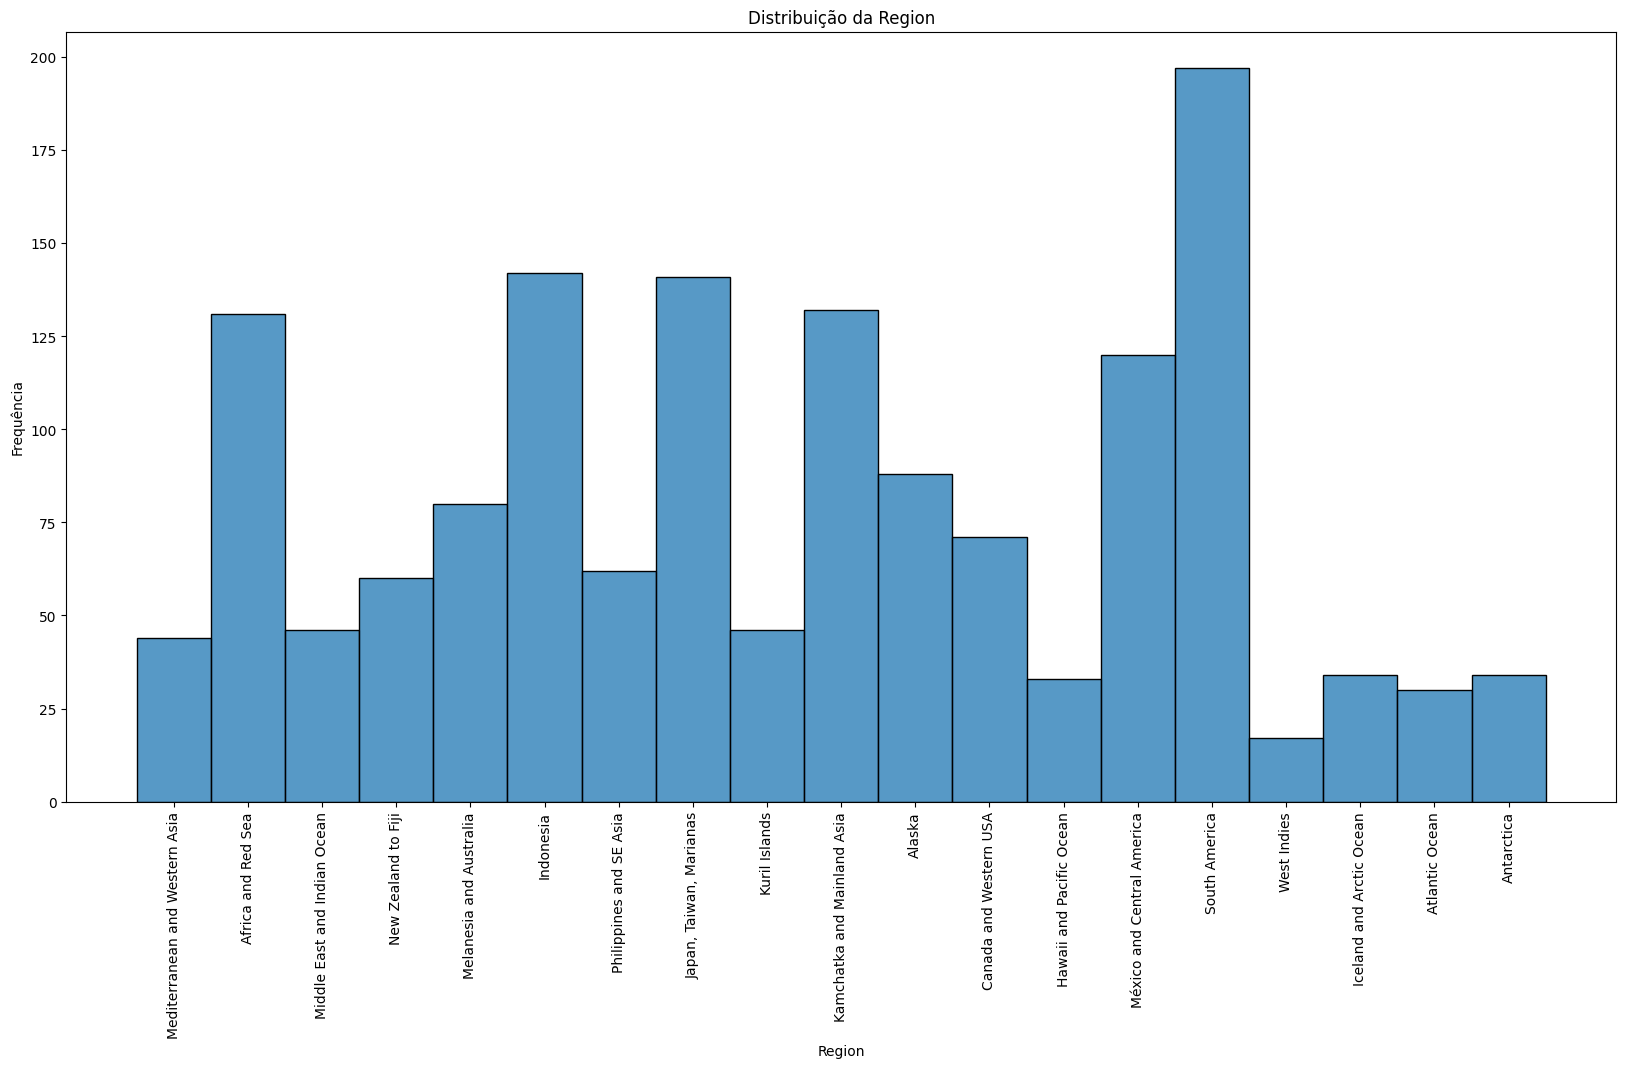

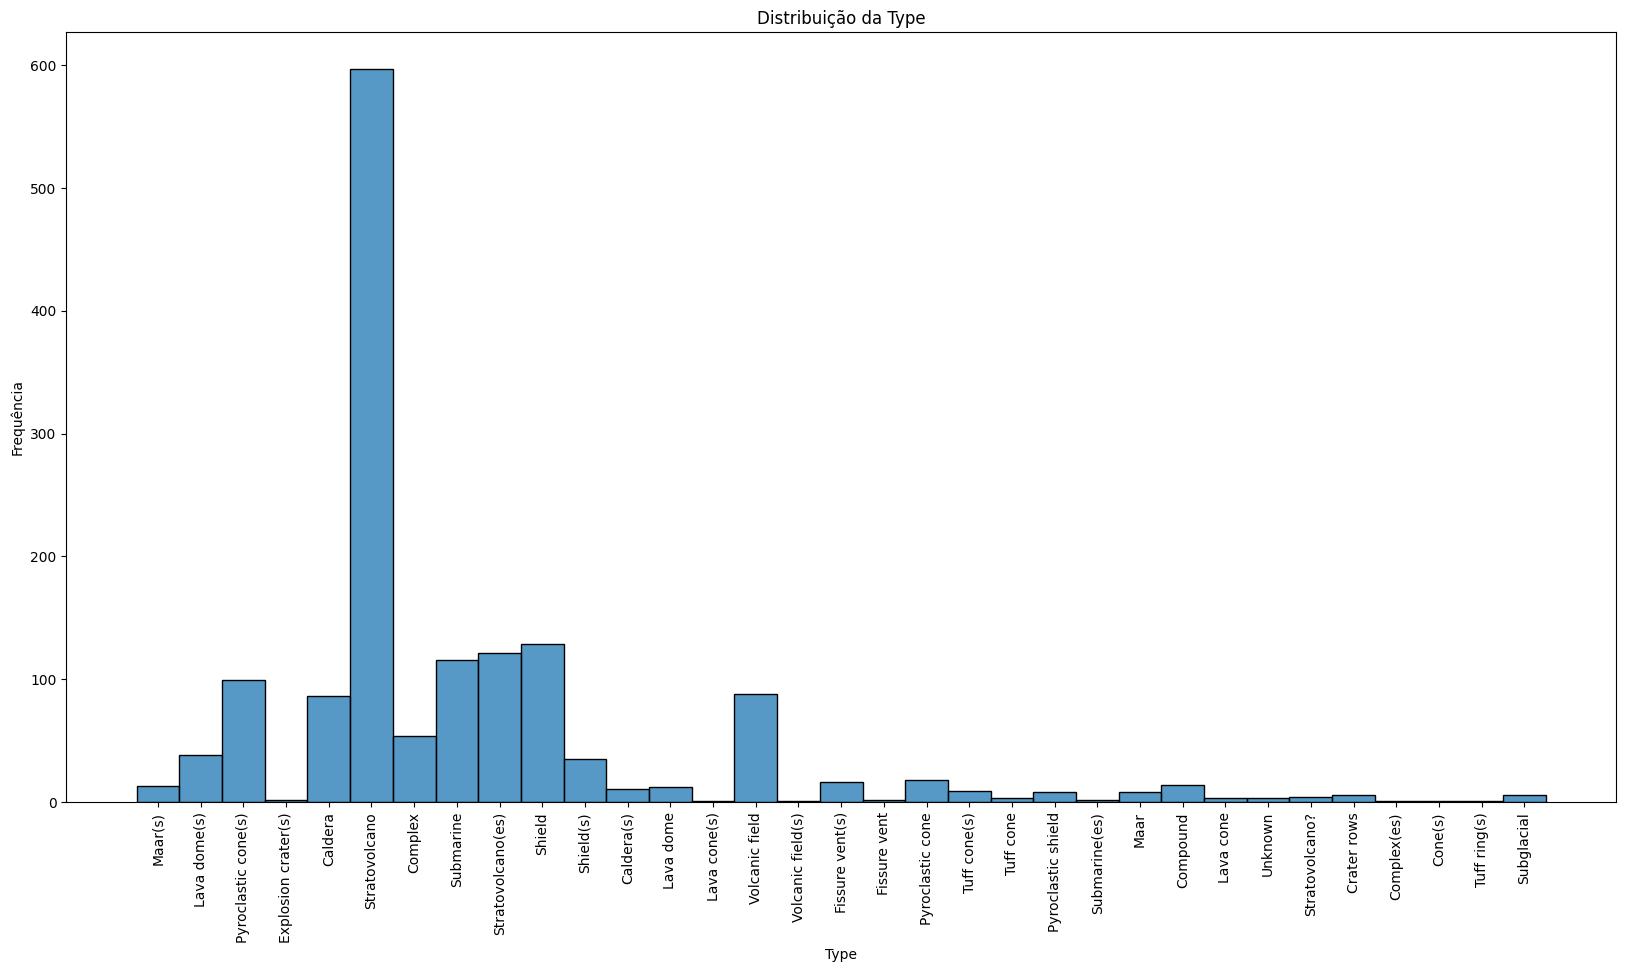

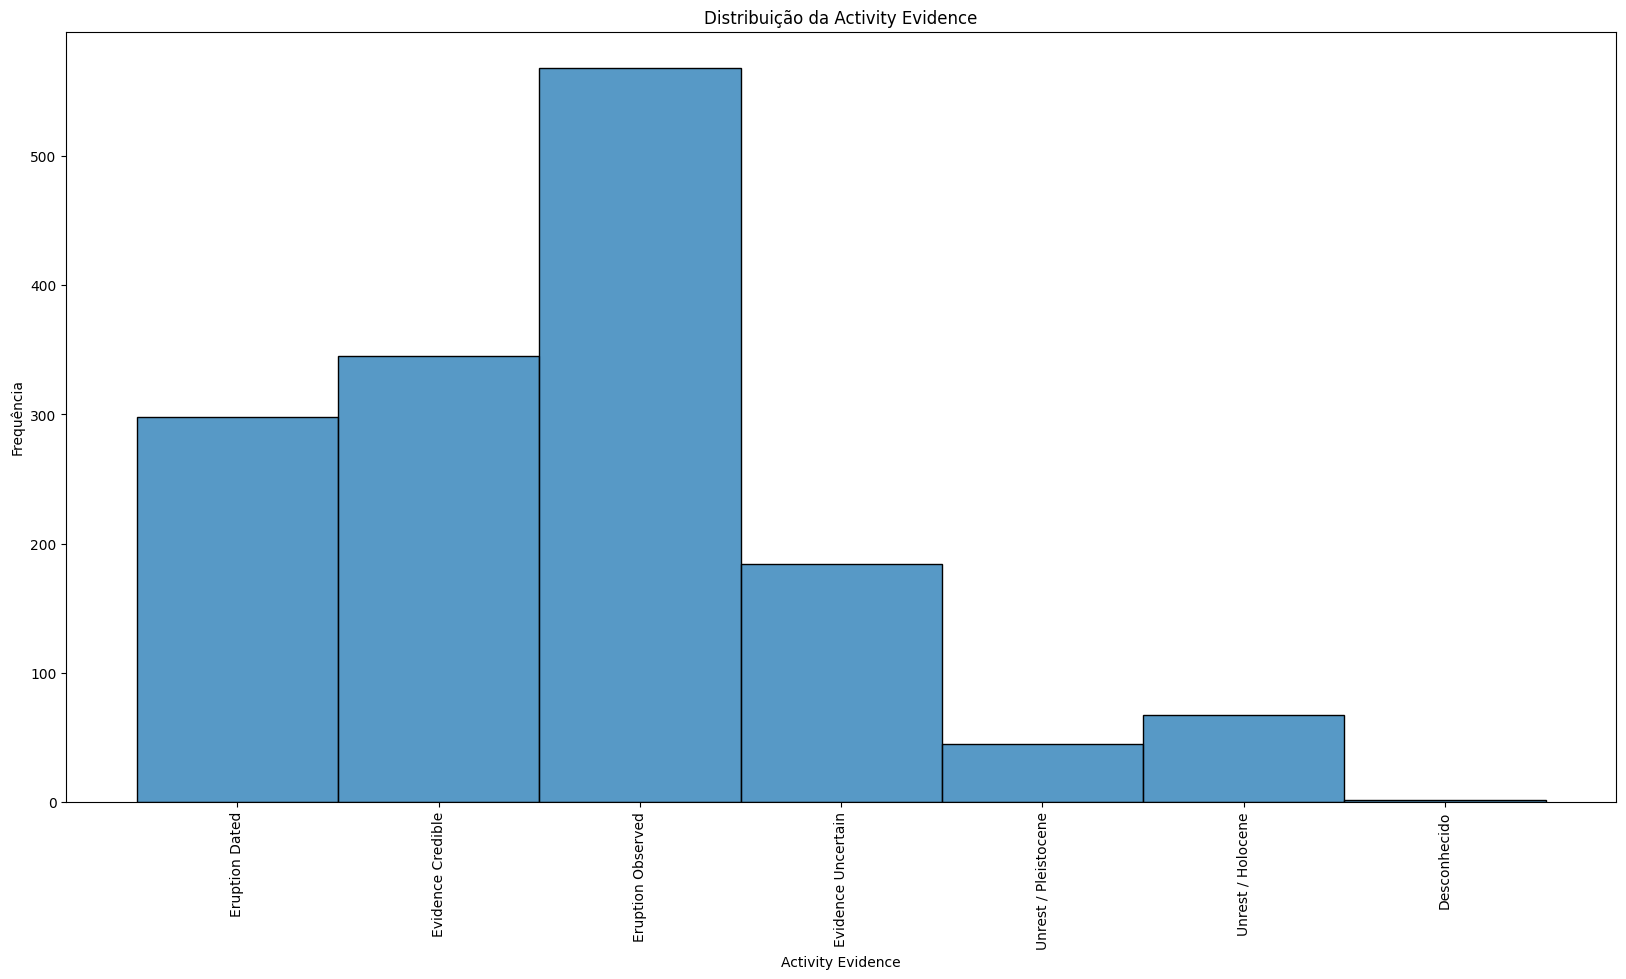

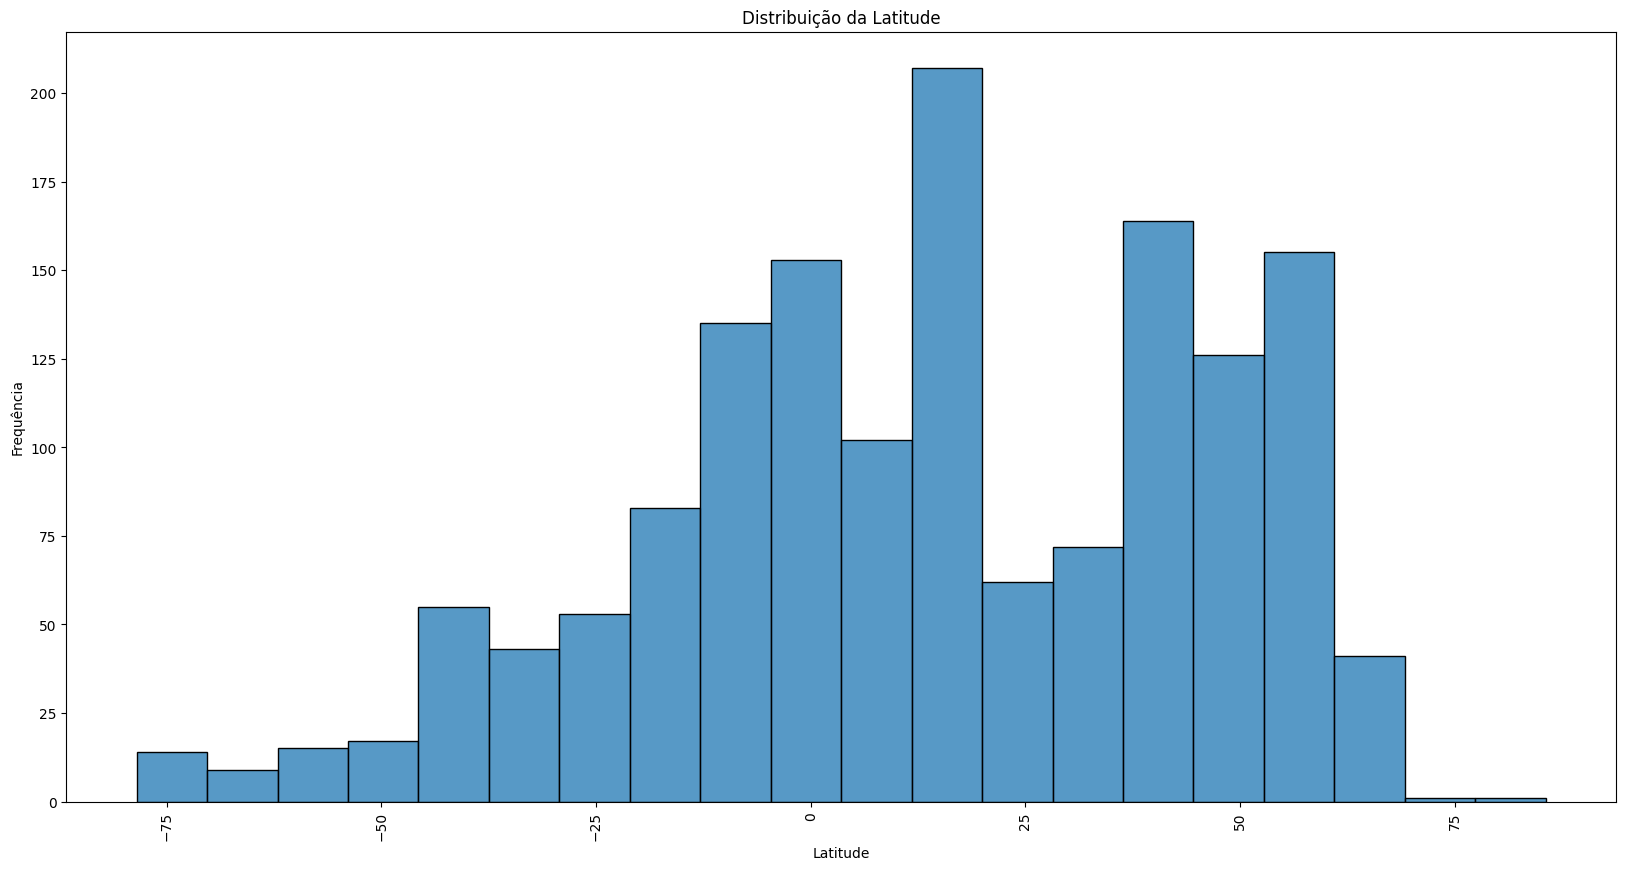

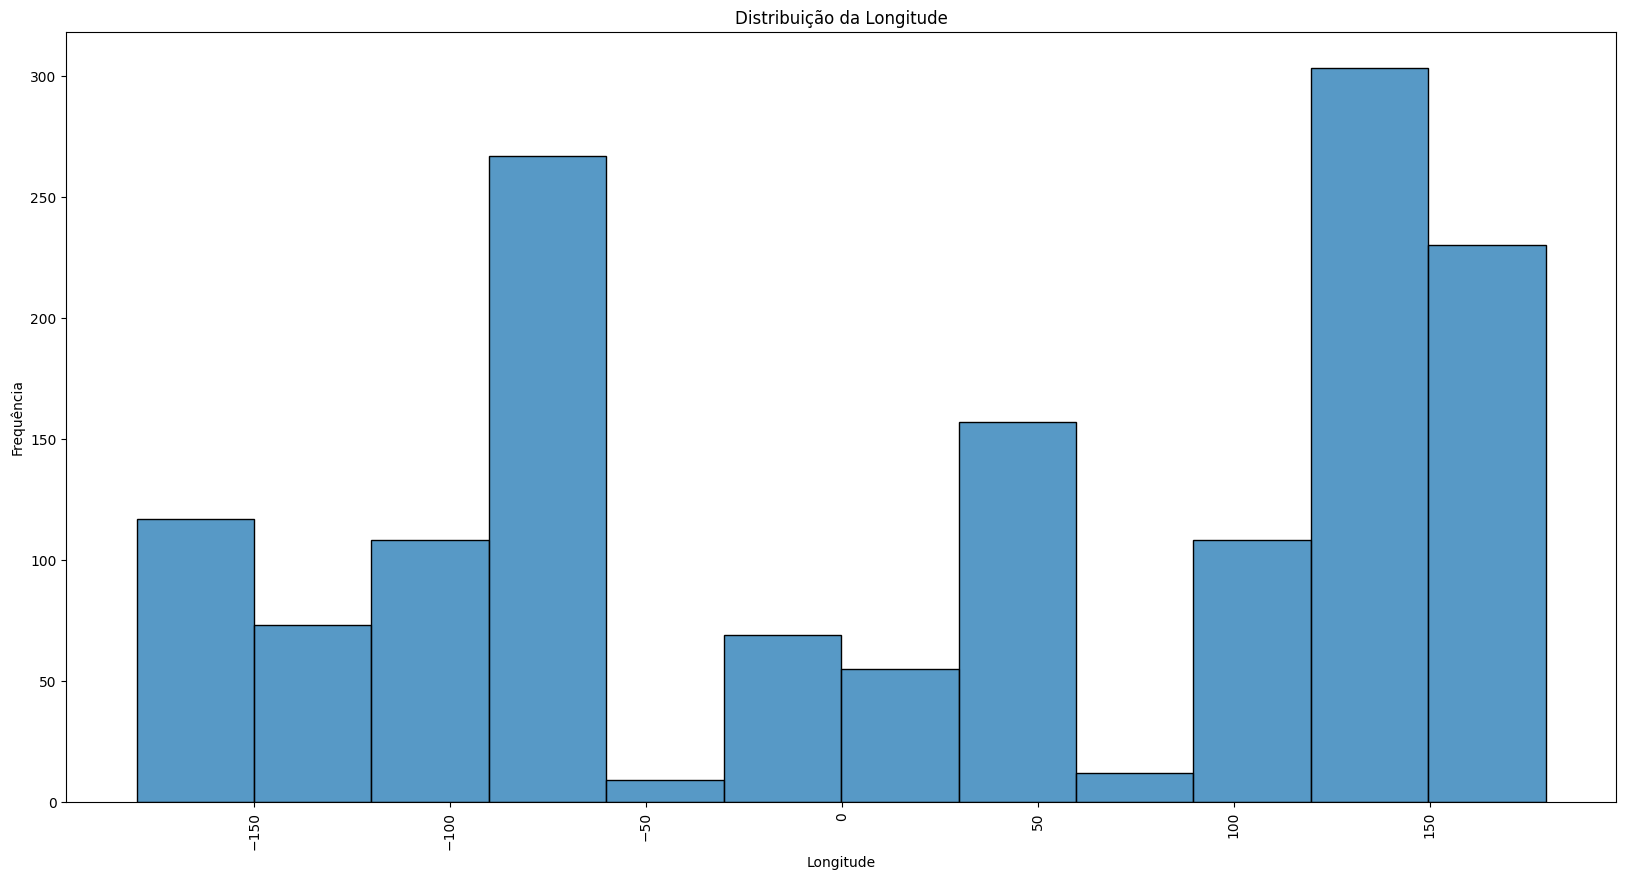

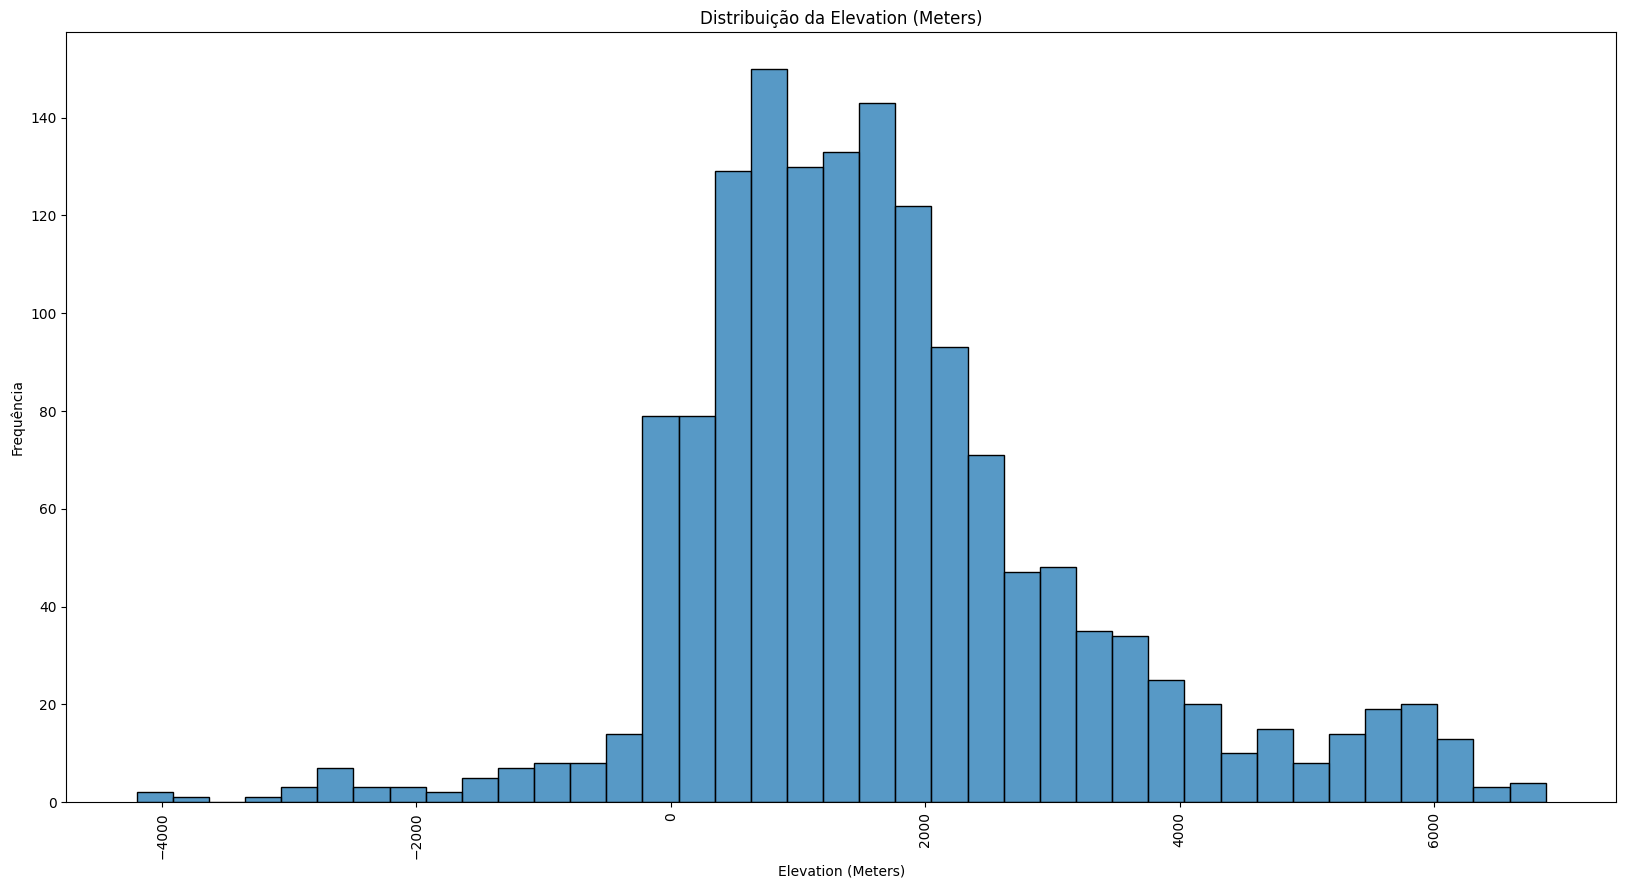

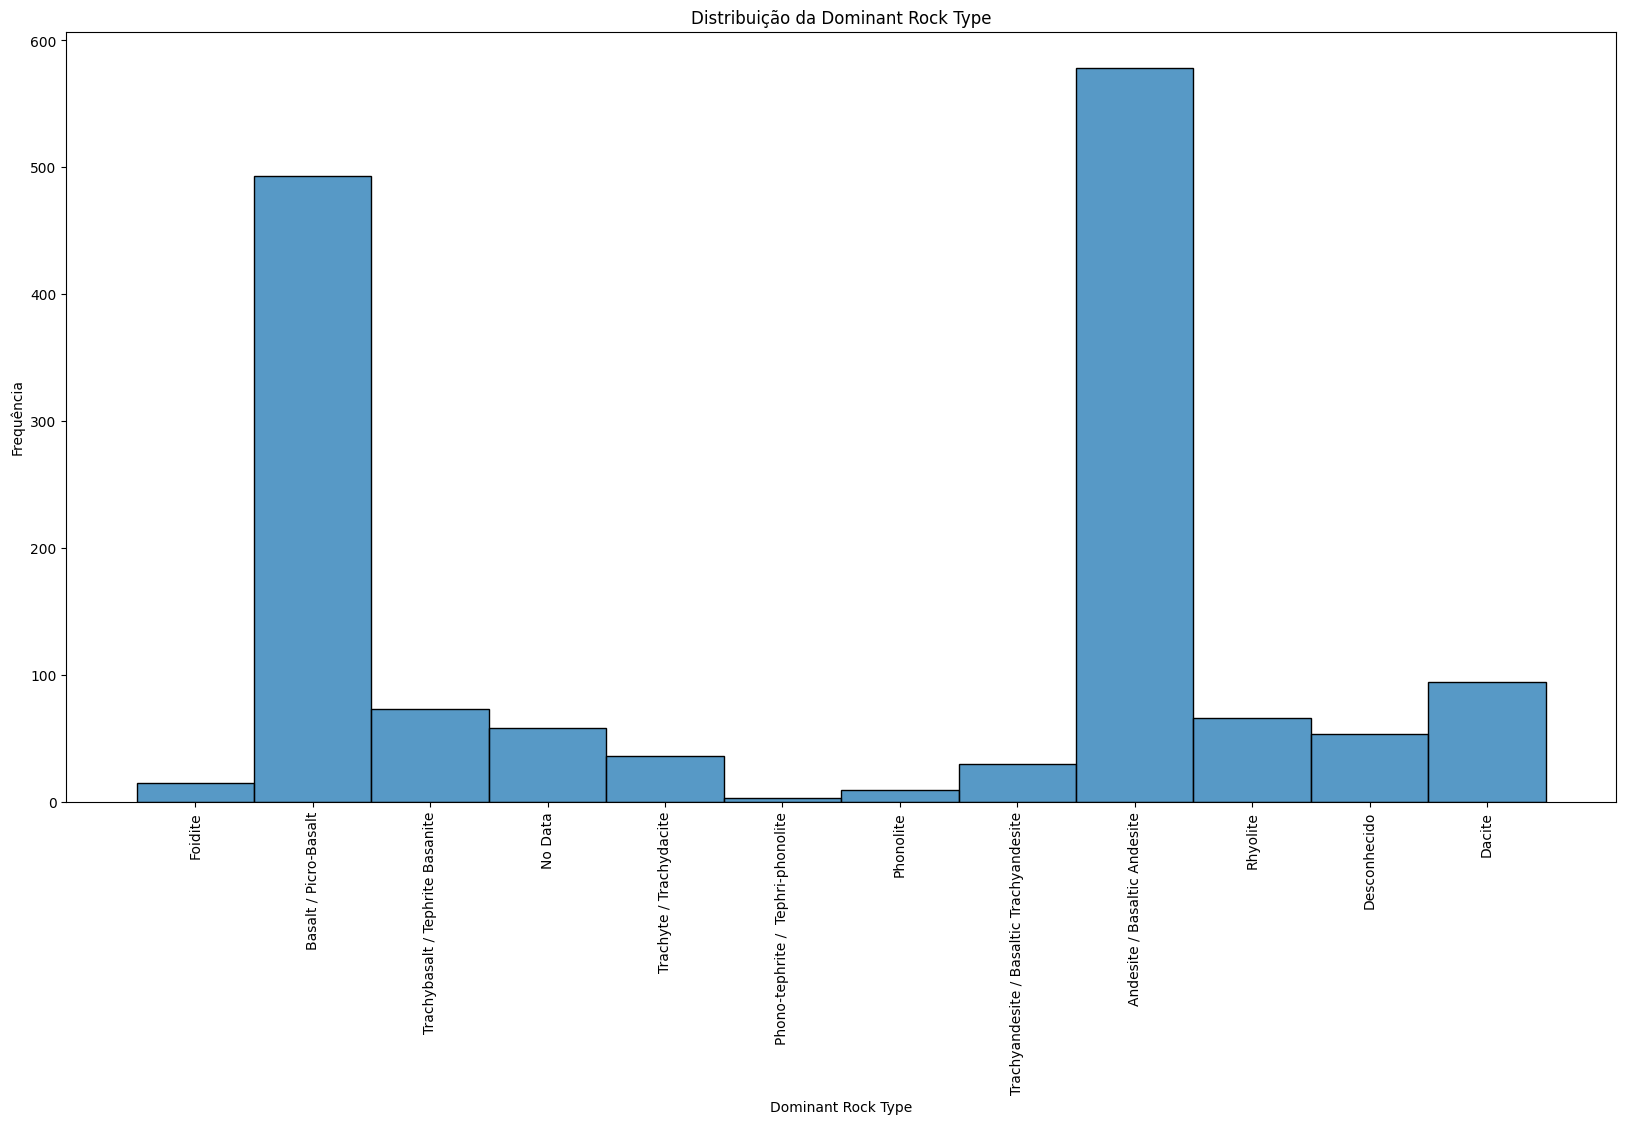

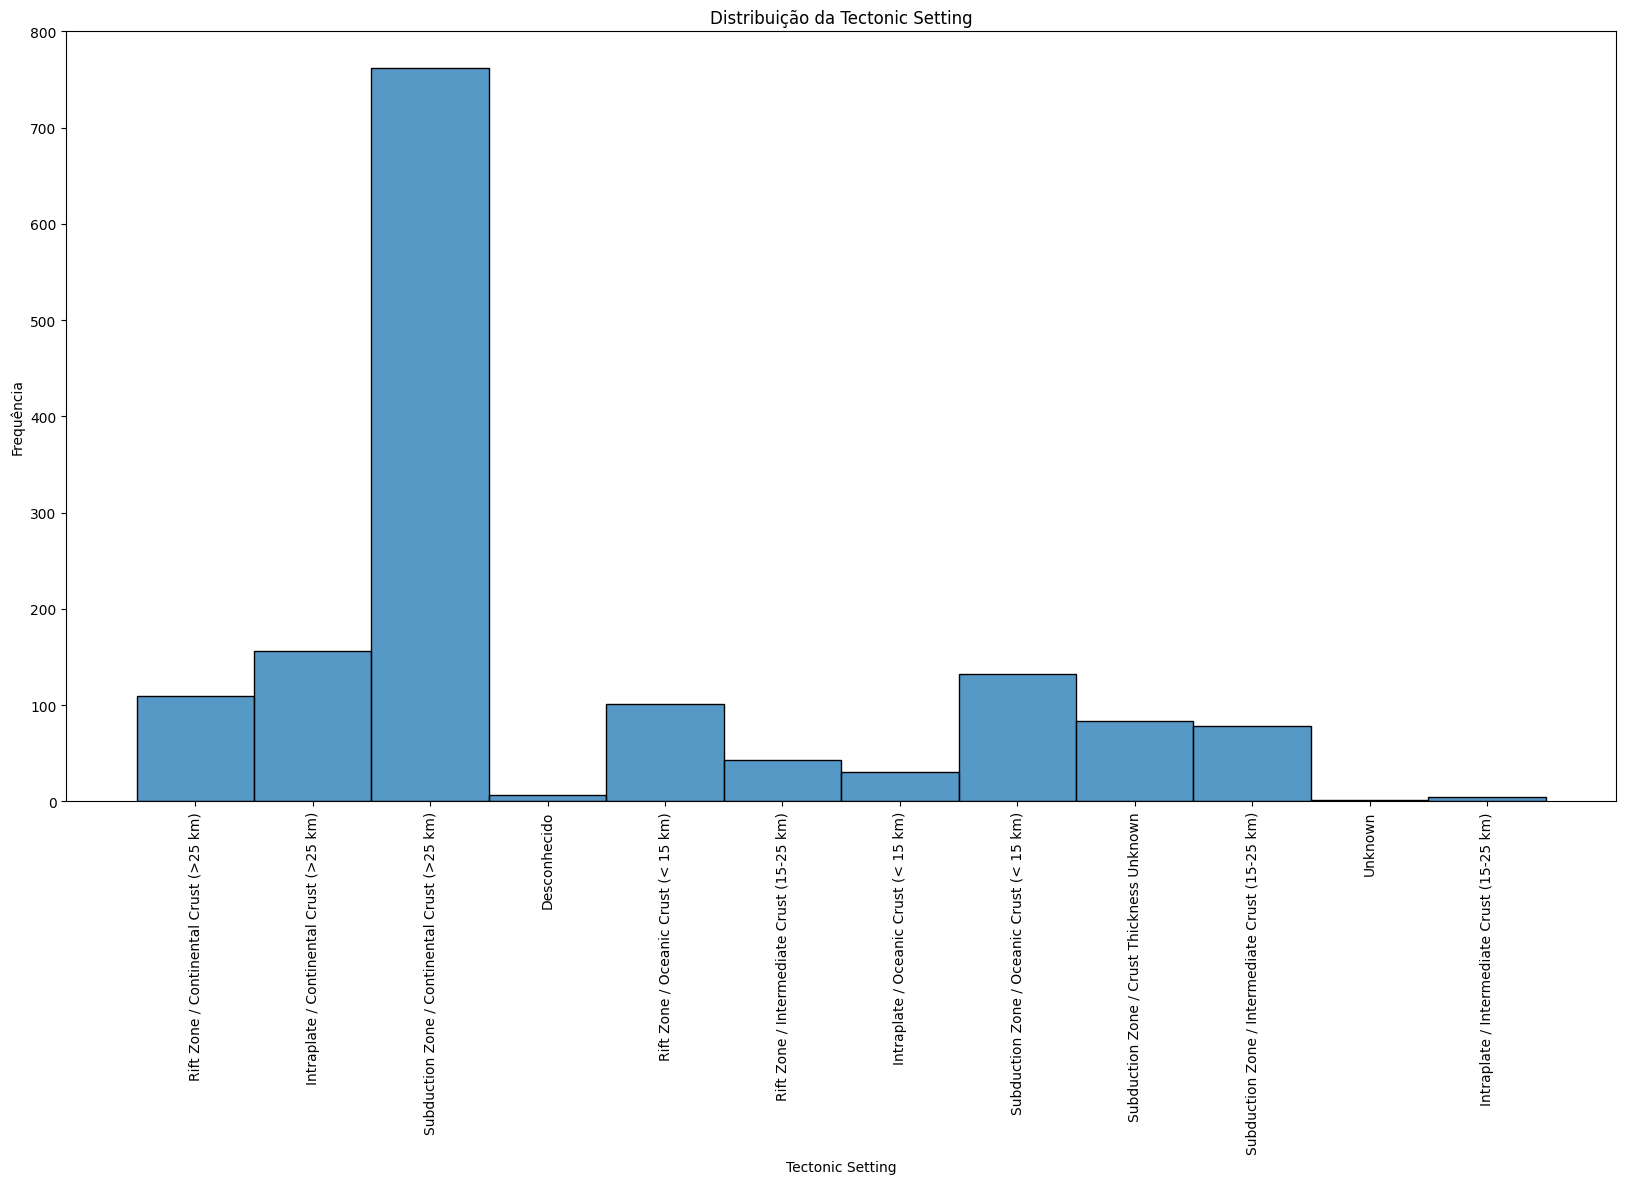

In [10]:
col_pular = ['int64', 'float64', 'Name', 'Last Known Eruption', '']
for col in df.columns:
    if col in col_pular:
        continue
    plt.figure(figsize=(20,10))
    sns.histplot(df[col], kde=False)
    plt.title(f'Distribuição da {col}')
    plt.xlabel(f'{col}')
    plt.xticks(rotation=90)
    plt.ylabel('Frequência')
    plt.show()

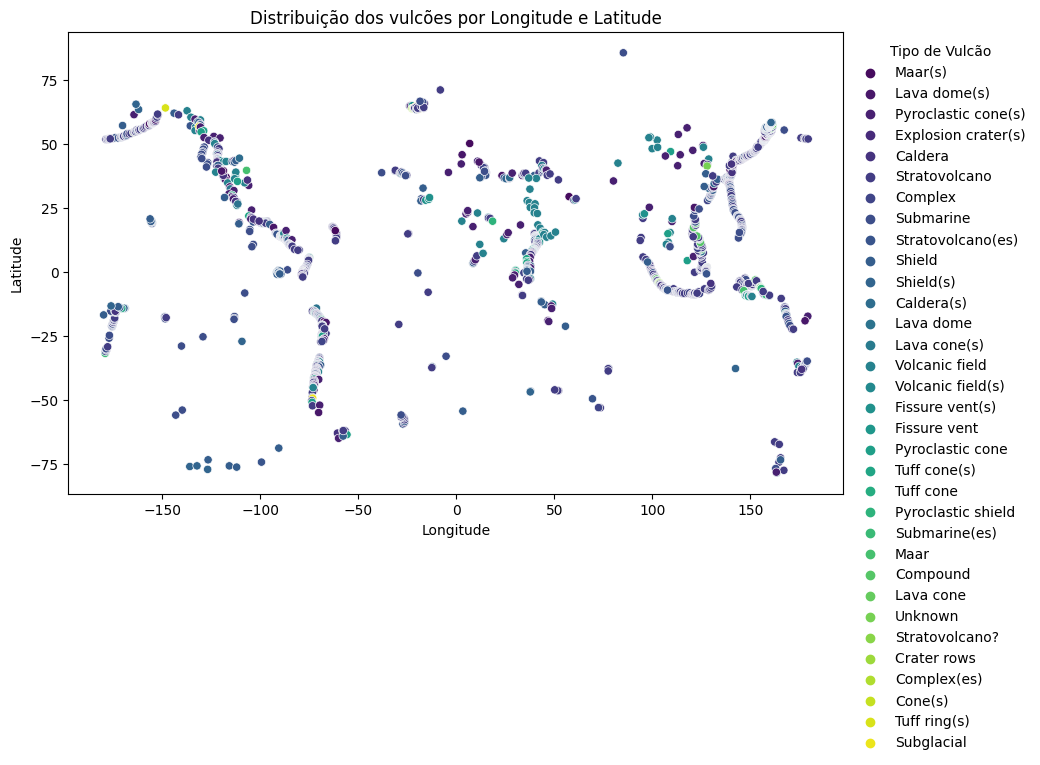

In [11]:
#Gráfico da dispersão entre Longitude, latitude e o tipo de vulcão que temos

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='Type', palette='viridis')
plt.title('Distribuição dos vulcões por Longitude e Latitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Tipo de Vulcão', loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=10)
plt.show()

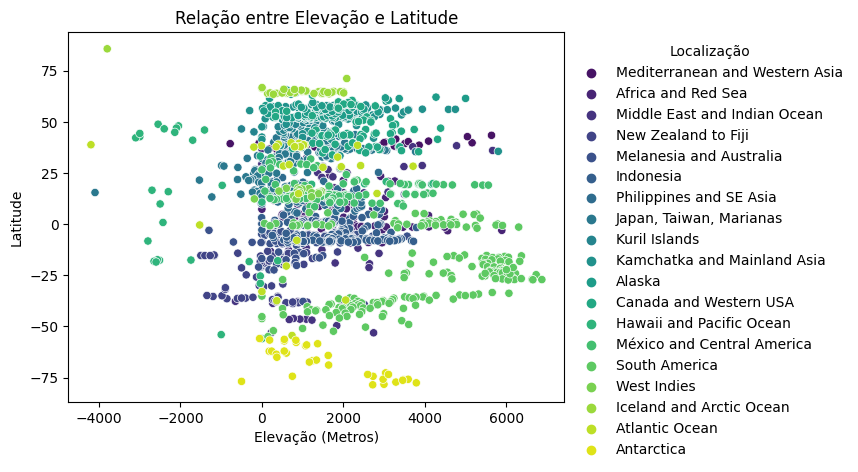

In [12]:
# Gráfico de dispersão entre Elevation, Latitude e a Região

sns.scatterplot(data=df, x='Elevation (Meters)', y='Latitude', hue='Region', palette='viridis')
plt.title('Relação entre Elevação e Latitude')
plt.xlabel('Elevação (Metros)')
plt.ylabel('Latitude')
plt.legend(title='Localização', loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=10)
plt.show()

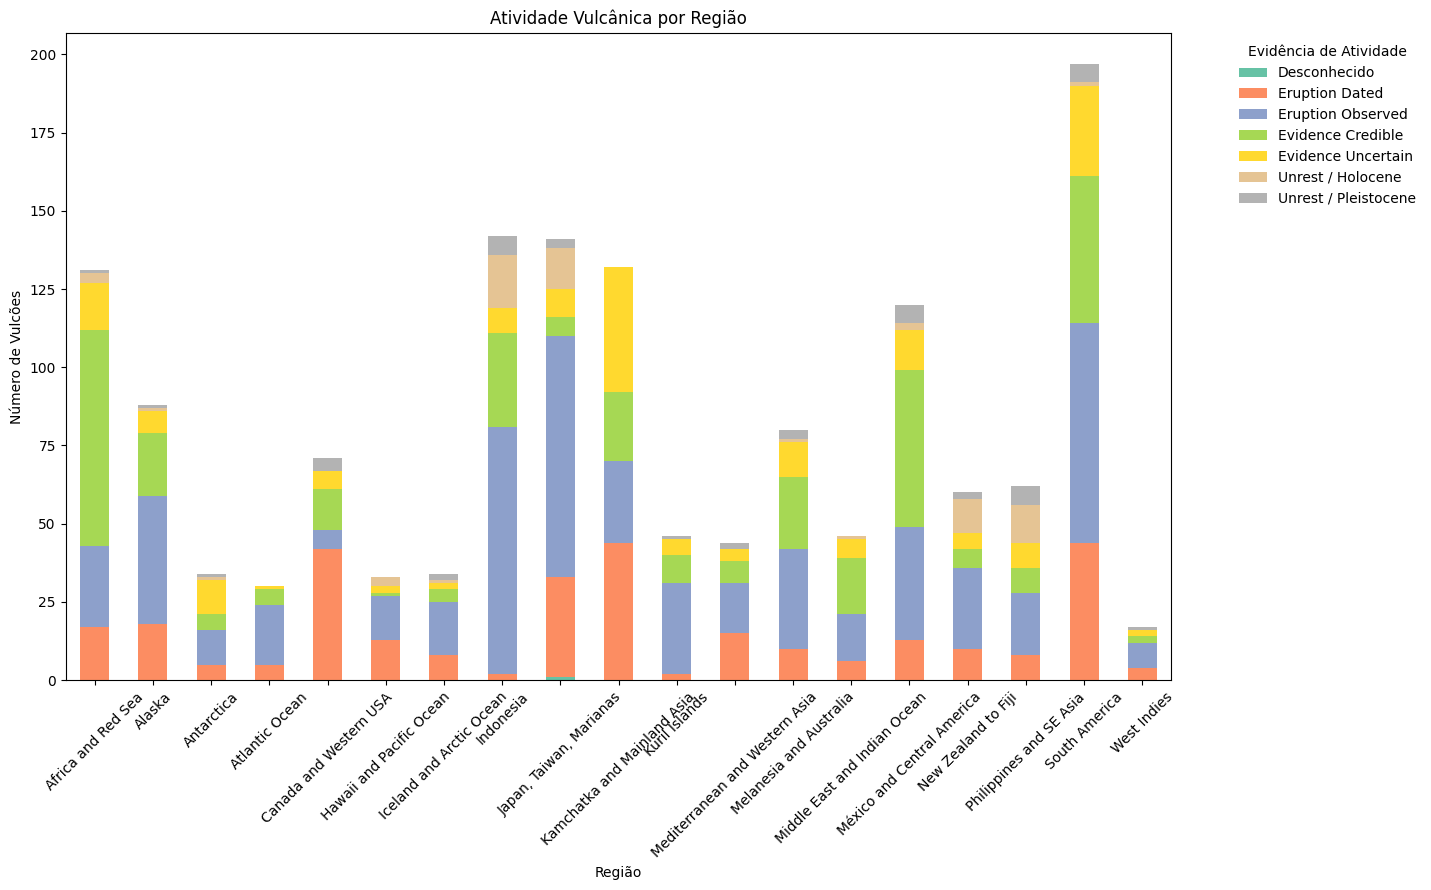

In [13]:
# Verificar a atividade vulcânica por Região
activity_by_region = df.groupby('Region')['Activity Evidence'].value_counts().unstack().fillna(0)

activity_by_region.plot(kind='bar', stacked=True, figsize=(12, 9), colormap='Set2')
plt.title('Atividade Vulcânica por Região')
plt.xlabel('Região')
plt.ylabel('Número de Vulcões')
plt.xticks(rotation=45)
plt.legend(title='Evidência de Atividade')
plt.tight_layout()
plt.legend(title='Evidência de Atividade', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.show()